### Import Libraries and Dataset

In [20]:
import pandas as pd
import numpy as np

In [21]:
# 1. Load Raw CoAD Dataset

df_coad_raw = pd.read_csv(r"D:\Plateful_of_Data_Datathon26\FAOSTAT_Dataset\FAOSTAT_CoAHD_Ghana.csv")

df_coad_raw.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Release,Unit,Value,Flag,Flag Description
0,CAHD,Cost and Affordability of a Healthy Diet (CoAHD),288,Ghana,6226,Value,70040,Cost of a healthy diet (CoHD),2017,2017,July 2026 (SOFI report),Int$ (PPP) per person per day,3.54,E,Estimated value
1,CAHD,Cost and Affordability of a Healthy Diet (CoAHD),288,Ghana,6226,Value,70040,Cost of a healthy diet (CoHD),2018,2018,July 2026 (SOFI report),Int$ (PPP) per person per day,3.51,E,Estimated value
2,CAHD,Cost and Affordability of a Healthy Diet (CoAHD),288,Ghana,6226,Value,70040,Cost of a healthy diet (CoHD),2019,2019,July 2026 (SOFI report),Int$ (PPP) per person per day,3.48,E,Estimated value
3,CAHD,Cost and Affordability of a Healthy Diet (CoAHD),288,Ghana,6226,Value,70040,Cost of a healthy diet (CoHD),2020,2020,July 2026 (SOFI report),Int$ (PPP) per person per day,3.46,E,Estimated value
4,CAHD,Cost and Affordability of a Healthy Diet (CoAHD),288,Ghana,6226,Value,70040,Cost of a healthy diet (CoHD),2021,2021,July 2026 (SOFI report),Int$ (PPP) per person per day,3.50,E,Estimated value


In [22]:
df_coad_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       48 non-null     str    
 1   Domain            48 non-null     str    
 2   Area Code (M49)   48 non-null     int64  
 3   Area              48 non-null     str    
 4   Element Code      48 non-null     int64  
 5   Element           48 non-null     str    
 6   Item Code         48 non-null     int64  
 7   Item              48 non-null     str    
 8   Year Code         48 non-null     int64  
 9   Year              48 non-null     int64  
 10  Release           48 non-null     str    
 11  Unit              48 non-null     str    
 12  Value             48 non-null     float64
 13  Flag              48 non-null     str    
 14  Flag Description  48 non-null     str    
dtypes: float64(1), int64(5), str(9)
memory usage: 12.7 KB


In [23]:
# 2. Selecting Core Columns & Dropping Redundant Codes/Flags

cols_to_keep = ['Year', 'Item Code', 'Item', 'Unit', 'Value']
df_clean = df_coad_raw[cols_to_keep].copy()
df_clean.head()

,Year,Item Code,Item,Unit,Value
0,2017,70040,Cost of a healthy diet (CoHD),Int$ (PPP) per person per day,3.54
1,2018,70040,Cost of a healthy diet (CoHD),Int$ (PPP) per person per day,3.51
2,2019,70040,Cost of a healthy diet (CoHD),Int$ (PPP) per person per day,3.48
3,2020,70040,Cost of a healthy diet (CoHD),Int$ (PPP) per person per day,3.46
4,2021,70040,Cost of a healthy diet (CoHD),Int$ (PPP) per person per day,3.50


### TABLE A: Annual Time-Series of Macro Affordability Metrics (2017–2025)

In [24]:
# Extract Cost of a Healthy Diet in Local Currency (GHS)

cohd_ghs = df_clean[(df_clean['Item'] == 'Cost of a healthy diet (CoHD)') & (df_clean['Unit'] == 'LCU/cap/d')][['Year', 'Value']].rename(columns={'Value': 'CoHD_GHS_day'})
cohd_ppp = df_clean[(df_clean['Item'] == 'Cost of a healthy diet (CoHD)') & (df_clean['Unit'] == 'Int$ (PPP) per person per day')][['Year', 'Value']].rename(columns={'Value': 'CoHD_PPP_day'})
pua = df_clean[df_clean['Item'] == 'Prevalence of unaffordability (PUA)'][['Year', 'Value']].rename(columns={'Value': 'PUA_pct'})
nua = df_clean[df_clean['Item'] == 'Number of people unable to afford a healthy diet (NUA)'][['Year', 'Value']].rename(columns={'Value': 'NUA_millions'})

df_coad_ts = cohd_ghs.merge(cohd_ppp, on='Year').merge(pua, on='Year').merge(nua, on='Year')

df_coad_ts

,Year,CoHD_GHS_day,CoHD_PPP_day,PUA_pct,NUA_millions
0,2017,6.05,3.54,67.2,20.2
1,2018,6.53,3.51,66.1,20.2
2,2019,7.01,3.48,64.8,20.3
3,2020,7.79,3.46,65.6,20.9
4,2021,8.59,3.50,64.7,21.1
5,2022,11.43,3.83,64.7,21.5
6,2023,16.99,4.29,66.4,22.4
7,2024,21.18,4.49,65.8,22.6
8,2025,24.81,4.65,65.8,23.1


In [25]:
# Feature Engineering
df_coad_ts['Nominal_Inflation_Multiplier'] = np.round(df_coad_ts['CoHD_GHS_day'] / df_coad_ts['CoHD_GHS_day'].iloc[0], 2)
df_coad_ts['YoY_Growth_Pct'] = np.round(df_coad_ts['CoHD_GHS_day'].pct_change() * 100, 1)

In [26]:
df_coad_ts['Nominal_Inflation_Multiplier']

0    1.00
1    1.08
2    1.16
3    1.29
4    1.42
5    1.89
6    2.81
7    3.50
8    4.10
Name: Nominal_Inflation_Multiplier, dtype: float64

In [27]:
df_coad_ts['YoY_Growth_Pct'] 

0     NaN
1     7.9
2     7.4
3    11.1
4    10.3
5    33.1
6    48.6
7    24.7
8    17.1
Name: YoY_Growth_Pct, dtype: float64

## TABLE B: Food Group Cost Breakdown (2021 Benchmark)

In [28]:
# Feature Engineering: Year-over-Year Growth & Total Inflation Multiplier
df_coad_ts['CoHD_GHS_YoY_Growth_%'] = np.round(df_coad_ts['CoHD_GHS_day'].pct_change() * 100, 2)
df_coad_ts['Cumulative_Inflation_Multiplier'] = np.round(df_coad_ts['CoHD_GHS_day'] / df_coad_ts['CoHD_GHS_day'].iloc[0], 2)

df_coad_ts

,Year,CoHD_GHS_day,CoHD_PPP_day,PUA_pct,NUA_millions,Nominal_Inflation_Multiplier,YoY_Growth_Pct,CoHD_GHS_YoY_Growth_%,Cumulative_Inflation_Multiplier
0,2017,6.05,3.54,67.2,20.2,1.00,NaN,NaN,1.00
1,2018,6.53,3.51,66.1,20.2,1.08,7.9,7.93,1.08
2,2019,7.01,3.48,64.8,20.3,1.16,7.4,7.35,1.16
3,2020,7.79,3.46,65.6,20.9,1.29,11.1,11.13,1.29
4,2021,8.59,3.50,64.7,21.1,1.42,10.3,10.27,1.42
5,2022,11.43,3.83,64.7,21.5,1.89,33.1,33.06,1.89
6,2023,16.99,4.29,66.4,22.4,2.81,48.6,48.64,2.81
7,2024,21.18,4.49,65.8,22.6,3.50,24.7,24.66,3.50
8,2025,24.81,4.65,65.8,23.1,4.10,17.1,17.14,4.10


## Data Visualizations 

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

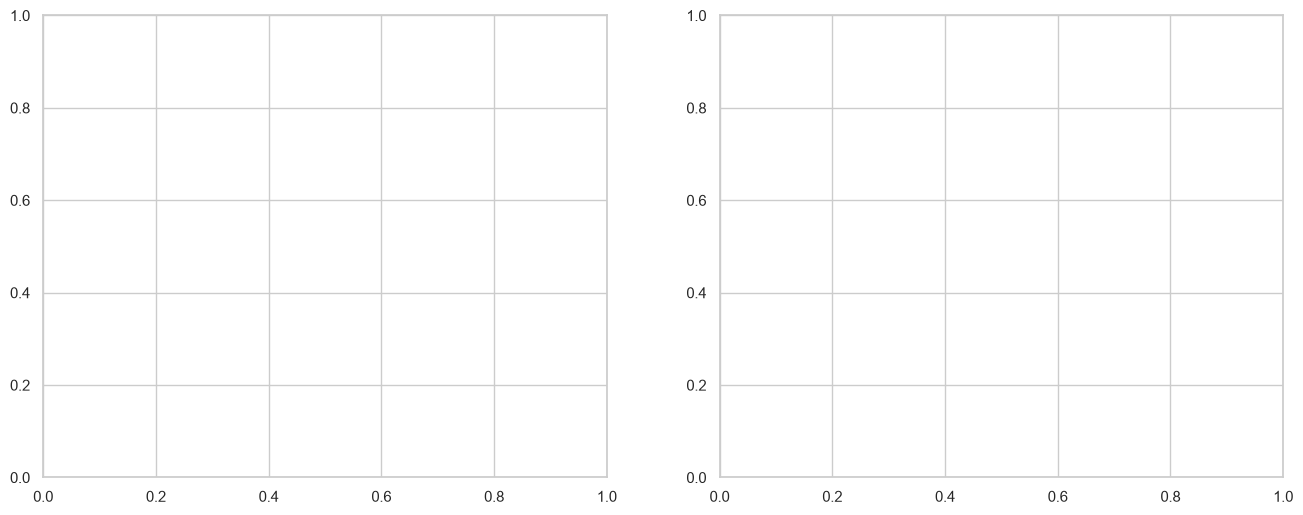

In [30]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

In [31]:
# Chart 1: Dual-Axis Cost Surge vs. Population Headcount

ax1 = axes[0]
color_line = '#c0392b'  # Deep crimson
color_bar = '#2980b9'   # Steel blue

ax1.set_xlabel('Year', fontweight='bold', fontsize=11)
ax1.set_ylabel('Cost of Healthy Diet (GHS / person / day)', color=color_line, fontweight='bold', fontsize=11)
ax1.plot(df_coad_ts['Year'], df_coad_ts['CoHD_GHS_day'], color=color_line, marker='o', linewidth=2.8, label='Diet Cost (GHS/day)')
ax1.tick_params(axis='y', labelcolor=color_line)

In [32]:
# Annotations for start and end points
ax1.annotate('2017: 6.05 GHS\n($3.54 PPP)', (2017, 6.05), textcoords="offset points", xytext=(-5, 12), fontweight='bold', color=color_line, fontsize=9)
ax1.annotate('2025: 24.81 GHS\n($4.65 PPP)', (2025, 24.81), textcoords="offset points", xytext=(-35, -30), fontweight='bold', color=color_line, fontsize=9)

Text(-35, -30, '2025: 24.81 GHS\n($4.65 PPP)')

In [33]:
# Secondary axis: Unaffordable population in millions
ax1_twin = ax1.twinx()
ax1_twin.set_ylabel('Population Unable to Afford (Millions)', color=color_bar, fontweight='bold', fontsize=11)
ax1_twin.bar(df_coad_ts['Year'], df_coad_ts['NUA_millions'], color=color_bar, alpha=0.35, width=0.45, label='Unaffordable Pop (M)')
ax1_twin.tick_params(axis='y', labelcolor=color_bar)
ax1_twin.set_ylim(15, 26)

ax1.set_title('(A) Ghana: Healthy Diet Cost Inflation & Unaffordability (2017–2025)', fontweight='bold', fontsize=12, pad=12)

Text(0.5, 1.0, '(A) Ghana: Healthy Diet Cost Inflation & Unaffordability (2017–2025)')

In [36]:
# Chart 2: 2021 Itemized Cost Driver Breakdown
ax2 = axes[1]
sns.barplot(data=df_cost_groups, x='Cost_Share_Pct', y='Food_Group', palette='Reds_r', ax=ax2)
ax2.set_title('(B) Animal-Source Foods Drive 41.1% of Healthy Diet Costs (2021)', fontweight='bold', fontsize=12, pad=12)
ax2.set_xlabel('Share of Total Daily Diet Cost (%)', fontweight='bold', fontsize=11)
ax2.set_ylabel('')

NameError: name 'df_cost_groups' is not defined

In [35]:
# Annotate bars with % and dollar values
for p, (_, row) in zip(ax2.patches, df_cost_groups.iterrows()):
    width = p.get_width()
    ax2.annotate(f"{width:.1f}% (${row['Cost_PPP_day']:.2f})", 
                 (width + 0.8, p.get_y() + p.get_height() / 2.), 
                 va='center', fontsize=9.5, fontweight='bold', color='#78281f')

ax2.set_xlim(0, 50)
fig.tight_layout()
plt.savefig('coad_analysis_dashboard.png', dpi=300)
plt.show()

NameError: name 'df_cost_groups' is not defined